<a href="https://colab.research.google.com/github/ambikeshchaurasia/E-coustumer_data_analysis/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv("data.csv", encoding='ISO-8859-1')

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


Convert date Column

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
# Create a new columns for revenue and calculate Revenue

In [11]:
df['Revenue']=df['Quantity']*df['UnitPrice']

In [12]:
df.isnull().sum() #for check empty Value

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0
Revenue,0


In [13]:
df.duplicated().sum() # for duplicat value

np.int64(5268)

In [14]:
df=df.drop_duplicates() # remove duplicat

In [15]:
df['Month']=df['InvoiceDate'].dt.to_period('M')

In [16]:
df[['InvoiceDate','Month']].head(5)

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [ ]:
# Claculate Monthly Sales

In [48]:
monthly_sales=df.groupby('Month')['Revenue'].sum().round(2)
print(monthly_sales)

Month
2010-12     746723.61
2011-01     558448.56
2011-02     497026.41
2011-03     682013.98
2011-04     492367.84
2011-05     722094.10
2011-06     689977.23
2011-07     680156.99
2011-08     681386.46
2011-09    1017596.68
2011-10    1069368.23
2011-11    1456145.80
2011-12     432701.06
Freq: M, Name: Revenue, dtype: float64


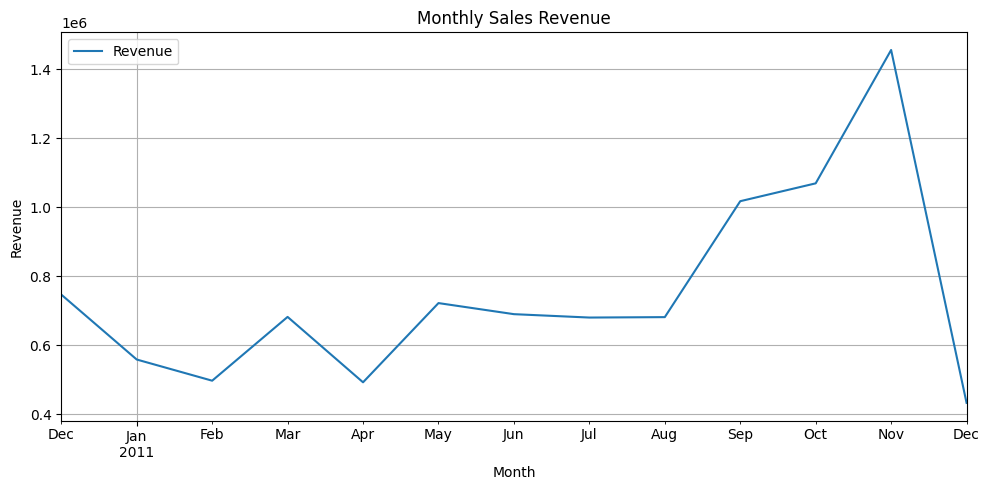

In [49]:
import matplotlib.pyplot as plt
monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#  top 10 country sales

In [56]:
country_sales=df.groupby('Country')['Revenue'].sum().round(2).sort_values(ascending=False).head(10)
print(country_sales)

Country
United Kingdom    8167128.18
Netherlands        284661.54
EIRE               262993.38
Germany            221509.47
France             197317.11
Australia          137009.77
Switzerland         56363.05
Spain               54756.03
Belgium             40910.96
Sweden              36585.41
Name: Revenue, dtype: float64


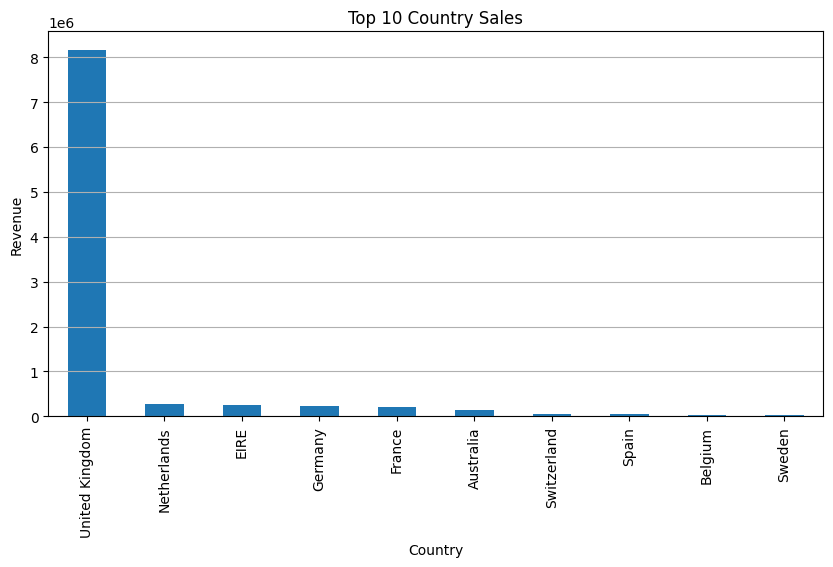

In [58]:
country_sales.plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Country Sales')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.grid(True,axis='y')
plt.show()

In [ ]:
# top 10 Products Revenue

In [50]:
top_products=df.groupby('Description')['Revenue'].sum().round(2).sort_values(ascending=False).head(10)
print(top_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Revenue, dtype: float64


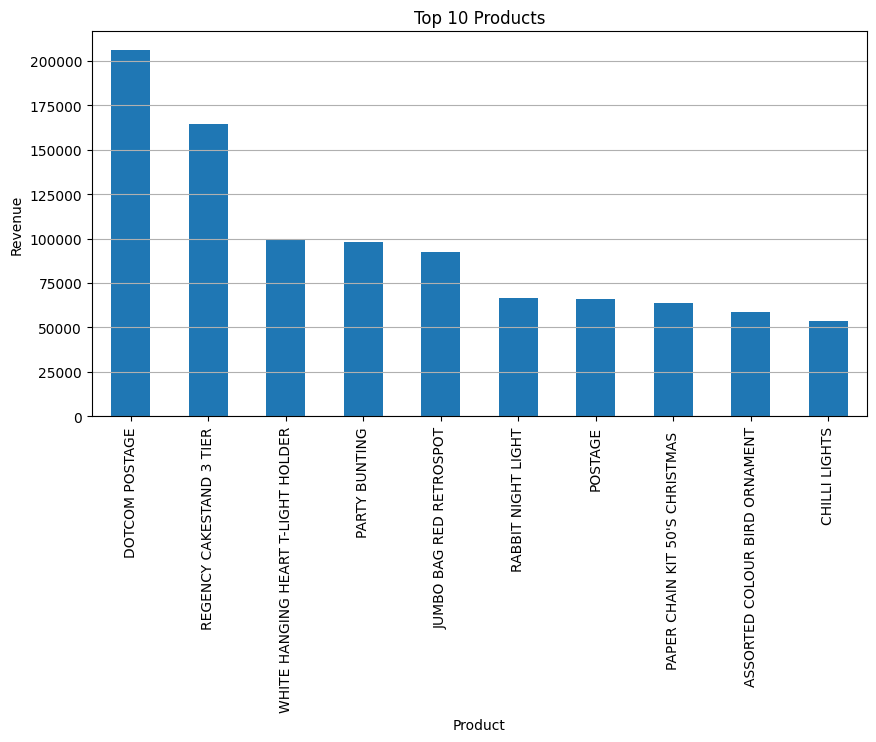

In [51]:
top_products.plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Products')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.grid(True,axis='y')
plt.show()

In [52]:
total_revenue = df['Revenue'].sum().round(2)
total_orders = df['InvoiceNo'].nunique()
total_products = df['Description'].nunique()
total_coustomers=df['CustomerID'].nunique()

print('Total Revenue =',total_revenue)
print('Total Orders =',total_orders)
print('Total Products =',total_products)
print('Total Coustomers =',total_coustomers)

Total Revenue = 9726006.95
Total Orders = 25900
Total Products = 4223
Total Coustomers = 4372


In [55]:
df.to_csv('cleaned_data.csv',index=False)
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010-12
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010-12
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010-12
